# Assignment 1
**余沛翰 72510479**

## Task 1 频率分析破解单表替换密码

**以下代码为VibeCoding内容**

In [ ]:
import random
from collections import Counter

# -------------------- 标准英语频率数据 --------------------
std_single = {
    'e': 12.7, 't': 9.1, 'a': 8.2, 'o': 7.5, 'i': 7.0, 'n': 6.7, 's': 6.3, 'h': 6.1,
    'r': 6.0, 'd': 4.3, 'l': 4.0, 'u': 2.8, 'c': 2.8, 'm': 2.4, 'w': 2.4, 'f': 2.2,
    'y': 2.0, 'g': 2.0, 'p': 1.9, 'b': 1.5, 'v': 1.0, 'k': 0.8, 'x': 0.2, 'j': 0.2,
    'q': 0.1, 'z': 0.1
}

std_bigram = {
    'th': 3.56, 'he': 3.07, 'in': 2.43, 'er': 2.05, 'an': 1.99, 're': 1.85, 'on': 1.76,
    'at': 1.49, 'en': 1.45, 'nd': 1.35, 'ti': 1.34, 'es': 1.34, 'or': 1.28, 'te': 1.20,
    'of': 1.17, 'ed': 1.17, 'is': 1.13, 'it': 1.12, 'al': 1.09, 'ar': 1.07, 'st': 1.05,
    'to': 1.05, 'nt': 1.04, 'ng': 0.95, 'se': 0.93, 'ha': 0.93, 'as': 0.87, 'ou': 0.87,
    'io': 0.83, 'le': 0.83, 've': 0.83, 'co': 0.79, 'me': 0.79, 'de': 0.76, 'hi': 0.76,
    'ri': 0.73, 'ro': 0.73, 'ic': 0.70, 'ne': 0.69, 'ea': 0.69, 'ra': 0.69, 'ce': 0.65
}

std_trigram = {
    'the': 1.81, 'and': 0.73, 'tha': 0.33, 'ent': 0.42, 'ing': 0.72, 'ion': 0.42,
    'tio': 0.31, 'for': 0.34, 'oft': 0.22, 'sth': 0.21
}

# -------------------- 统计密文 --------------------
def count_ngrams(text):
    """统计密文中单字母、双字母、三字母的出现次数"""
    letters = [c for c in text if c.isalpha() and c.islower()]
    total_chars = len(letters)
    
    char_count = Counter(letters)
    
    bigrams = [letters[i] + letters[i+1] for i in range(total_chars - 1)]
    bigram_count = Counter(bigrams)
    total_bigrams = len(bigrams)
    
    trigrams = [letters[i] + letters[i+1] + letters[i+2] for i in range(total_chars - 2)]
    trigram_count = Counter(trigrams)
    total_trigrams = len(trigrams)
    
    return char_count, bigram_count, trigram_count, total_chars, total_bigrams, total_trigrams

# -------------------- 评分函数（带权重）--------------------
def compute_score(mapping, char_count, bigram_count, trigram_count,
                  total_chars, total_bigrams, total_trigrams,
                  w_single=1.0, w_bigram=2.0, w_trigram=3.0):
    """
    根据当前映射计算加权总误差（越小越好）
    w_single, w_bigram, w_trigram 分别为单、双、三字母误差的权重
    """
    # 单字母频率
    plain_count = {p: 0 for p in std_single}
    for c, cnt in char_count.items():
        p = mapping[c]
        plain_count[p] += cnt
    single_score = 0
    for p, std_freq in std_single.items():
        freq = plain_count.get(p, 0) * 100.0 / total_chars
        single_score += (freq - std_freq) ** 2

    # 双字母频率
    new_bigram_count = {}
    for bg, cnt in bigram_count.items():
        p1, p2 = mapping[bg[0]], mapping[bg[1]]
        new_bg = p1 + p2
        new_bigram_count[new_bg] = new_bigram_count.get(new_bg, 0) + cnt
    bigram_score = 0
    for bg, std_freq in std_bigram.items():
        freq = new_bigram_count.get(bg, 0) * 100.0 / total_bigrams
        bigram_score += (freq - std_freq) ** 2

    # 三字母频率
    new_trigram_count = {}
    for tg, cnt in trigram_count.items():
        p1, p2, p3 = mapping[tg[0]], mapping[tg[1]], mapping[tg[2]]
        new_tg = p1 + p2 + p3
        new_trigram_count[new_tg] = new_trigram_count.get(new_tg, 0) + cnt
    trigram_score = 0
    for tg, std_freq in std_trigram.items():
        freq = new_trigram_count.get(tg, 0) * 100.0 / total_trigrams
        trigram_score += (freq - std_freq) ** 2

    return w_single * single_score + w_bigram * bigram_score + w_trigram * trigram_score

# -------------------- 爬山算法 --------------------
def hill_climb(initial_mapping, char_count, bigram_count, trigram_count,
               total_chars, total_bigrams, total_trigrams,
               max_iter=20000, w_single=1.0, w_bigram=2.0, w_trigram=3.0):
    mapping = initial_mapping.copy()
    current_score = compute_score(mapping, char_count, bigram_count, trigram_count,
                                  total_chars, total_bigrams, total_trigrams,
                                  w_single, w_bigram, w_trigram)
    cipher_letters = list('abcdefghijklmnopqrstuvwxyz')
    for _ in range(max_iter):
        c1, c2 = random.sample(cipher_letters, 2)
        new_mapping = mapping.copy()
        new_mapping[c1], new_mapping[c2] = new_mapping[c2], new_mapping[c1]
        new_score = compute_score(new_mapping, char_count, bigram_count, trigram_count,
                                  total_chars, total_bigrams, total_trigrams,
                                  w_single, w_bigram, w_trigram)
        if new_score < current_score:
            mapping = new_mapping
            current_score = new_score
    return mapping

# -------------------- 主程序 --------------------
def main():
    random.seed(42)

    with open('ciphertext.txt', 'r') as f:
        ciphertext = f.read()

    char_count, bigram_count, trigram_count, total_chars, total_bigrams, total_trigrams = count_ngrams(ciphertext)

    # 初始映射：按单字母频率降序对应
    std_letters_sorted = sorted(std_single.keys(), key=lambda x: (-std_single[x], x))
    all_cipher = list('abcdefghijklmnopqrstuvwxyz')
    cipher_sorted = sorted(all_cipher, key=lambda x: (-char_count.get(x, 0), x))

    initial_mapping = {}
    for c, p in zip(cipher_sorted, std_letters_sorted):
        initial_mapping[c] = p

    print("初始映射（基于单字母频率）:")
    for c in sorted(initial_mapping.keys()):
        print(f"{c} -> {initial_mapping[c]}")

    # 设置权重：单:双:三 = 1:5:10，以优先保证双三字母频率
    w_single, w_bigram, w_trigram = 1.0, 5.0, 10.0

    final_mapping = hill_climb(initial_mapping, char_count, bigram_count, trigram_count,
                               total_chars, total_bigrams, total_trigrams,
                               max_iter=20000, w_single=w_single, w_bigram=w_bigram, w_trigram=w_trigram)

    print("\n优化后最终映射（双/三字母权重更高）:")
    for c in sorted(final_mapping.keys()):
        print(f"{c} -> {final_mapping[c]}")

    # 生成 tr 命令
    cipher_order = 'abcdefghijklmnopqrstuvwxyz'
    plain_order = ''.join(final_mapping[c] for c in cipher_order)
    tr_cmd = f"tr '{cipher_order}' '{plain_order}' < ciphertext.txt > plaintext.txt"
    print("\n" + "="*50)
    print("建议使用的 tr 命令：")
    print(tr_cmd)
    print("="*50)

if __name__ == "__main__":
    main()

初始映射（基于单字母频率）:
a -> c
b -> f
c -> u
d -> b
e -> p
f -> v
g -> g
h -> h
i -> d
j -> j
k -> x
l -> w
m -> s
n -> e
o -> q
p -> l
q -> n
r -> y
s -> k
t -> r
u -> i
v -> a
w -> z
x -> o
y -> t
z -> m

优化后最终映射（双/三字母权重更高）:
a -> c
b -> f
c -> w
d -> b
e -> p
f -> v
g -> m
h -> r
i -> l
j -> j
k -> x
l -> y
m -> i
n -> e
o -> q
p -> d
q -> s
r -> g
s -> k
t -> h
u -> n
v -> a
w -> z
x -> o
y -> t
z -> u

建议使用的 tr 命令：
tr 'abcdefghijklmnopqrstuvwxyz' 'cfwbpvmrljxyieqdsgkhnazotu' < ciphertext.txt > plaintext.txt


经肉眼观察，将映射修改以下内容：
- r -> w
- l -> m
- g -> b
- d -> y

**最终调整命令：**

```bash

tr 'abcdefghijklmnopqrstuvwxyz' 'cfmypvbrljxwieqdsgkhnazotu' < ciphertext.txt > plaintext.txt

```

**原文（部分）**

```txt
the oscars turn  on sunday which seems about right after this long strange
awards trip the bagger feels like a nonagenarian too

the awards race was bookended by the demise of harvey weinstein at its outset
and the apparent implosion of his film company at the end and it was shaped by
the emergence of metoo times up blackgown politics armcandy activism and
```

---

## Task 2 使用不同密码和模式加密

1. 使用三种不同的密码/模式加密

```bash
openssl enc -aes-128-cbc -e -in plain.txt -out cipher1.bin -K 00112233445566778889aabbccddeeff -iv 0102030405060708
openssl enc -bf-cbc -e -in plain.txt -out cipher2.bin -K 00112233445566778889aabbccddeeff -iv 0102030405060708
openssl enc -aes-128-cfb -e -in plain.txt -out cipher3.bin -K 00112233445566778889aabbccddeeff -iv 0102030405060708
```

2. 分别解密验证：

```bash
openssl enc -aes-128-cbc -d -in cipher1.bin -out dec1.txt -K 00112233445566778889aabbccddeeff -iv 0102030405060708
cat dec1.txt
```

3. 记录加密后文件的大小

```bash
ls -l cipher*.bin
```
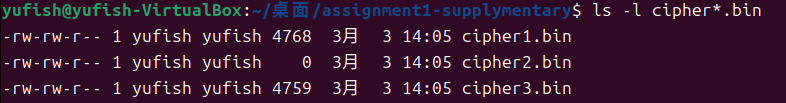

---

## Task 3 ECB vs. CBC 模式对图片加密的影响

1. 使用ECB模式加密图片（保留原始文件头以便后续拼接）：

```bash
openssl enc -aes-128-ecb -e -in pic_original.bmp -out pic_ecb.bin -K 00112233445566778889aabbccddeeff -iv 0000000000000000
```

2. 使用CBC模式加密图片：

```bash
openssl enc -aes-128-cbc -e -in pic_original.bmp -out pic_cbc.bin -K 00112233445566778889aabbccddeeff -iv 0102030405060708
```

3. 从原始图片提取前54字节头部：

```bash
head -c 54 pic_original.bmp > header
```

4. 分别从加密文件提取从55字节开始的数据：

```bash
tail -c +55 pic_ecb.bin > body_ecb
tail -c +55 pic_cbc.bin > body_cbc
```

5. 组合头部与加密数据生成新的BMP文件：

```bash
cat header body_ecb > new_ecb.bmp
cat header body_cbc > new_cbc.bmp
```

6. 用图片查看器打开new_ecb.bmp和new_cbc.bmp，观察图像

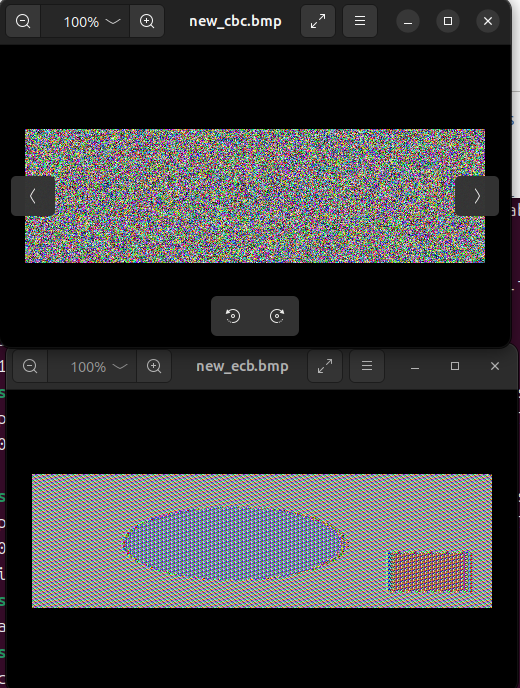

**可以看到的现象是ECB模式下图像轮廓依然可见（由于相同颜色块加密后相同），CBC模式下图像完全混乱。**

**ECB相同明文块加密成相同密文块，泄露了图像的模式；CBC通过链接使相同块加密结果则不同。**

---

## Task 4 填充机制分析

1. 测试哪些模式需要填充

分别用ECB、CBC、CFB、OFB模式加密文件

```bash
openssl enc -aes-128-ecb -e -in plain.txt -out test_ecb.bin -K 00112233445566778889aabbccddeeff
openssl enc -aes-128-cbc -e -in plain.txt -out test_cbc.bin -K 00112233445566778889aabbccddeeff -iv 0102030405060708
openssl enc -aes-128-cfb -e -in plain.txt -out test_cfb.bin -K 00112233445566778889aabbccddeeff -iv 0102030405060708
openssl enc -aes-128-ofb -e -in plain.txt -out test_ofb.bin -K 00112233445566778889aabbccddeeff -iv 0102030405060708
ls -l plain.txt test_*.bin
```

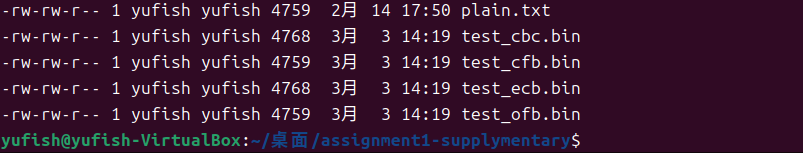

**CFB/OFB是流模式，不需要填充；ECB/CBC是块模式，需要填充到块大小倍数**

2. 观察PKCS#5填充内容

创建三个不同长度的文件

```bash
echo -n "12345" > f5.txt
echo -n "1234567890" > f10.txt
echo -n "1234567890123456" > f16.txt
```

分别用AES-128-CBC加密

```bash
openssl enc -aes-128-cbc -e -in f5.txt -out f5.enc -K 00112233445566778889aabbccddeeff -iv 0102030405060708
openssl enc -aes-128-cbc -e -in f10.txt -out f10.enc -K 00112233445566778889aabbccddeeff -iv 0102030405060708
openssl enc -aes-128-cbc -e -in f16.txt -out f16.enc -K 00112233445566778889aabbccddeeff -iv 0102030405060708
```

查看加密后文件大小


```bash
ls -l f*.enc
```

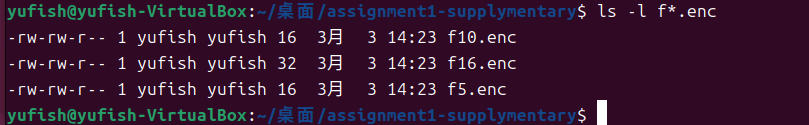

使用-nopad选项解密，保留填充数据

```bash
openssl enc -aes-128-cbc -d -nopad -in f5.enc -out f5.dec -K 00112233445566778889aabbccddeeff -iv 0102030405060708
openssl enc -aes-128-cbc -d -nopad -in f10.enc -out f10.dec -K 00112233445566778889aabbccddeeff -iv 0102030405060708
openssl enc -aes-128-cbc -d -nopad -in f16.enc -out f16.dec -K 00112233445566778889aabbccddeeff -iv 0102030405060708
```

用xxd查看解密后的文件内容

```bash
xxd f5.dec
xxd f10.dec
xxd f16.dec
```

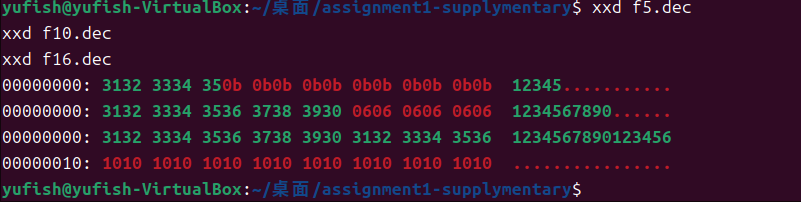

**PKCS#5填充中，每个填充字节的值等于填充的长度，所以16字节文件加密后变为32字节是因为增加了一整个填充块。**

---

## Task 5 错误传播——损坏的密文

1. 创建一个至少1000字节的文件

```bash
for i in {1..100}; do echo "This is a line of text for error propagation experiment." >> long.txt; done
```

2. 使用AES-128分别以ECB、CBC、CFB、OFB模式加密该文件

``` bash
openssl enc -aes-128-ecb -e -in long.txt -out long_ecb.enc -K 00112233445566778889aabbccddeeff
openssl enc -aes-128-cbc -e -in long.txt -out long_cbc.enc -K 00112233445566778889aabbccddeeff -iv 0102030405060708
openssl enc -aes-128-cfb -e -in long.txt -out long_cfb.enc -K 00112233445566778889aabbccddeeff -iv 0102030405060708
openssl enc -aes-128-ofb -e -in long.txt -out long_ofb.enc -K 00112233445566778889aabbccddeeff -iv 0102030405060708
```

3. 打开每个加密文件，定位到第55字节，修改其中的一个比特

```bash
for f in long_ecb.enc long_cbc.enc long_cfb.enc long_ofb.enc; do
    python3 -c "with open('$f', 'r+b') as fh: fh.seek(54); b = fh.read(1); fh.seek(54); fh.write(bytes([b[0] ^ 1]))"
done
```

4. 分别用正确密钥和IV解密损坏的文件

```bash
openssl enc -aes-128-ecb -d -in long_ecb.enc -out long_ecb_dec.txt -K 00112233445566778889aabbccddeeff
openssl enc -aes-128-cbc -d -in long_cbc.enc -out long_cbc_dec.txt -K 00112233445566778889aabbccddeeff -iv 0102030405060708
openssl enc -aes-128-cfb -d -in long_cfb.enc -out long_cfb_dec.txt -K 00112233445566778889aabbccddeeff -iv 0102030405060708
openssl enc -aes-128-ofb -d -in long_ofb.enc -out long_ofb_dec.txt -K 00112233445566778889aabbccddeeff -iv 0102030405060708
```

5. 查看比较解密后的文件与原始文件，观察哪些部分损坏

```bash
diff long.txt long_ecb_dec.txt
diff long.txt long_cbc_dec.txt
diff long.txt long_cfb_dec.txt
diff long.txt long_ofb_dec.txt
```

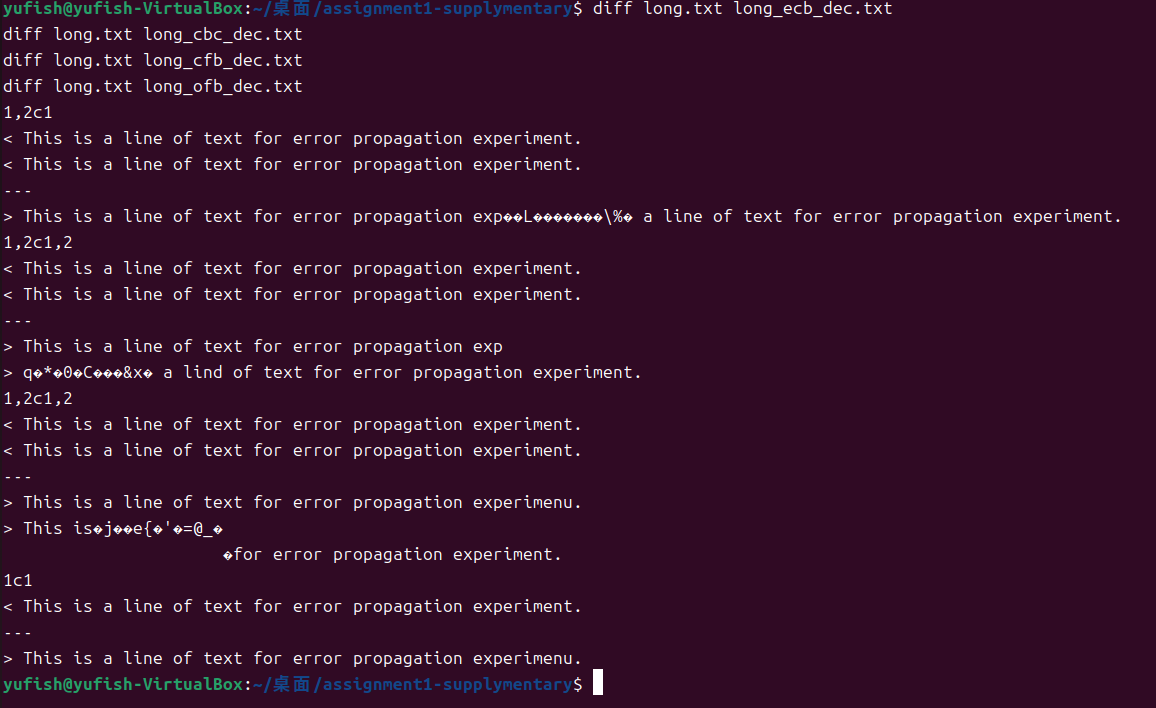

- ECB：只影响损坏密文所在的块（一个块16字节）。
- CBC：影响损坏块及其后一个块（因为解密时当前块需用前一密文）。
- CFB：影响损坏字节及其后一个块（取决于CFB的反馈位数，通常为8位或128位，此处以128位CFB为例，损坏一个字节会导致对应明文位置及后续一个块出错）。
- OFB：仅损坏对应位置的明文比特（因为密钥流独立，错误不传播）。

---

## Task 6 初始向量 (IV) 的安全性

### IV唯一性实验

1. 创建相同明文文件

```bash
echo -n "The same plaintext" > same.txt
```

2. 用相同密钥、相同IV加密两次

```bash
openssl enc -aes-128-cbc -e -in same.txt -out same_iv1.enc -K 00112233445566778889aabbccddeeff -iv 0102030405060708
openssl enc -aes-128-cbc -e -in same.txt -out same_iv2.enc -K 00112233445566778889aabbccddeeff -iv 0102030405060708
```

3. 用相同密钥、不同IV加密两次

```bash
openssl enc -aes-128-cbc -e -in same.txt -out diff_iv1.enc -K 00112233445566778889aabbccddeeff -iv 1111111111111111
openssl enc -aes-128-cbc -e -in same.txt -out diff_iv2.enc -K 00112233445566778889aabbccddeeff -iv 2222222222222222
```

4. 比较加密结果

```bash
cmp same_iv1.enc same_iv2.enc
cmp diff_iv1.enc diff_iv2.enc
```

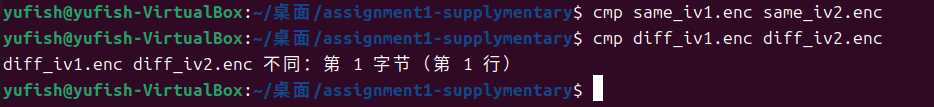

**IV保证了相同明文在不同加密中产生不同密文，防止模式识别和重放攻击**

### OFB模式已知明文攻击

已知数据

- 明文 P1
`P1: "This is a known message!"`

- 密文 C1
`C1 (十六进制): a469b1c502c1cab966965e50425438e1bb1b5f9037a4c159`

- 密文 C2
`C2 (十六进制): bf73bcd3509299d566c35b5d450337e1bb175f903fafc159`

In [2]:
def hex_to_bytes(hex_str):
    """将十六进制字符串转为字节，若长度为奇数则补0并警告"""
    if len(hex_str) % 2:
        hex_str += '0'
    return bytes.fromhex(hex_str)

def ofb_known_plaintext_attack(p1_str, c1_hex, c2_hex):
    # 转换明文为字节
    p1_bytes = p1_str.encode('ascii')
    # 转换密文为字节
    c1_bytes = hex_to_bytes(c1_hex)
    c2_bytes = hex_to_bytes(c2_hex)

    # 确保长度一致（取最短）
    min_len = min(len(p1_bytes), len(c1_bytes), len(c2_bytes))
    p1_bytes = p1_bytes[:min_len]
    c1_bytes = c1_bytes[:min_len]
    c2_bytes = c2_bytes[:min_len]

    # 计算密钥流
    keystream = bytes(a ^ b for a, b in zip(p1_bytes, c1_bytes))

    # 解密得到 P2
    p2_bytes = bytes(a ^ b for a, b in zip(c2_bytes, keystream))

    # 尝试解码为 ASCII（无法解码的字符用 '?' 替换）
    p2_str = p2_bytes.decode('ascii', errors='replace')
    return p2_str

if __name__ == "__main__":
    P1 = "This is a known message!"
    C1 = "a469b1c502c1cab966965e50425438e1bb1b5f9037a4c159"
    C2 = "bf73bcd3509299d566c35b5d450337e1bb175f903fafc159"

    result = ofb_known_plaintext_attack(P1, C1, C2)
    print("恢复的 P2 明文:", result)

恢复的 P2 明文: Order: Launch a missile!


### 可预测IV攻击（CBC模式）

In [3]:
from Crypto.Cipher import AES
from Crypto.Util.Padding import pad
import binascii

def bytes_xor(a, b):
    """按字节异或两个等长字节串"""
    return bytes(x ^ y for x, y in zip(a, b))

def attack_simulation(actual_plaintext):
    # 密钥（十六进制）
    key_hex = "00112233445566778899aabbccddeeff"
    key = binascii.unhexlify(key_hex)

    # IVs
    iv1_hex = "31323334353637383930313233343536"
    iv2_hex = "31323334353637383930313233343537"
    iv1 = binascii.unhexlify(iv1_hex)
    iv2 = binascii.unhexlify(iv2_hex)

    # 实际P1（假设为 "Yes" 或 "No"）
    p1_str = actual_plaintext
    p1 = pad(p1_str.encode(), 16)  # PKCS#7填充

    # Bob加密P1得到C1
    cipher = AES.new(key, AES.MODE_CBC, iv1)
    c1 = cipher.encrypt(p1)
    print(f"实际P1: {p1_str} (填充后: {p1.hex()})")
    print(f"C1: {c1.hex()}")

    # 攻击者猜测P1为"Yes"的填充块
    guess_yes = pad(b"Yes", 16)
    guess_no = pad(b"No", 16)

    # 构造P2，假设猜测为Yes
    p2 = bytes_xor(bytes_xor(iv2, iv1), guess_yes)
    # Bob用iv2加密P2
    cipher2 = AES.new(key, AES.MODE_CBC, iv2)
    c2 = cipher2.encrypt(p2)
    print(f"构造的P2 (猜测Yes): {p2.hex()}")
    print(f"得到的C2: {c2.hex()}")

    if c2 == c1:
        print("攻击结果: P1 是 Yes!")
    else:
        print("攻击结果: P1 是 No!")

# 测试两种情况
print("=== 情况1: 实际P1 = Yes ===")
attack_simulation("Yes")
print("\n=== 情况2: 实际P1 = No ===")
attack_simulation("No")

=== 情况1: 实际P1 = Yes ===
实际P1: Yes (填充后: 5965730d0d0d0d0d0d0d0d0d0d0d0d0d)
C1: bef65565572ccee2a9f9553154ed9498
构造的P2 (猜测Yes): 5965730d0d0d0d0d0d0d0d0d0d0d0d0c
得到的C2: bef65565572ccee2a9f9553154ed9498
攻击结果: P1 是 Yes!

=== 情况2: 实际P1 = No ===
实际P1: No (填充后: 4e6f0e0e0e0e0e0e0e0e0e0e0e0e0e0e)
C1: d0680746008a9e91d756e1301d209243
构造的P2 (猜测Yes): 5965730d0d0d0d0d0d0d0d0d0d0d0d0c
得到的C2: bef65565572ccee2a9f9553154ed9498
攻击结果: P1 是 No!


**攻击仅需一次加密询问，即可确定P1的内容**

---

## Task 7 编程使用Crypto库破解密钥

1. 编写C程序（例如find_key.c），使用OpenSSL EVP库进行AES-128-CBC解密尝试。流程：

    - 读取每个单词，长度小于16。

    - 构造密钥：单词字节后补足#（0x23）至16字节。

    - 用给定IV（十六进制字符串）和密文（十六进制字符串）尝试解密。

    - 比较解密结果的前21字节是否等于给定明文"This is a top secret."。

    - 若匹配，输出密钥单词。

2. 编译时链接crypto库：`gcc -o find_key find_key.c -lcrypto`

In [4]:
import binascii
from Crypto.Cipher import AES
from Crypto.Util.Padding import unpad

def try_decrypt(word, ciphertext, iv):
    """
    尝试用单词构造的密钥解密，返回解密后的明文（无填充）
    """
    # 构造密钥：单词字节 + 0x23填充到16字节
    key = word.encode('ascii')
    if len(key) >= 16:
        return None  # 单词太长，跳过
    key = key + b'\x23' * (16 - len(key))

    # 创建AES-CBC解密器
    cipher = AES.new(key, AES.MODE_CBC, iv)
    try:
        # 解密整个密文（两个块）
        decrypted = cipher.decrypt(ciphertext)
        # 尝试去除PKCS#7填充，若填充无效会抛出异常
        plain = unpad(decrypted, AES.block_size)
        return plain
    except (ValueError, KeyError):
        # 填充错误或解密失败
        return None

# 已知数据
plain_expected = b"This is a top secret."
cipher_hex = "764aa26b55a4da654df6b19e4bce00f4ed05e09346fb0e762583cb7da2ac93a2"
iv_hex = "aabbccddeeff00998877665544332211"

# 转换为字节
ciphertext = binascii.unhexlify(cipher_hex)
iv = binascii.unhexlify(iv_hex)

# 读取单词列表（假设words.txt与notebook同目录）
wordlist_path = "words.txt"
found_key = None

with open(wordlist_path, 'r', encoding='utf-8', errors='ignore') as f:
    for i, line in enumerate(f):
        word = line.strip()
        if not word or len(word) >= 16:
            continue
        # 每1000个词显示进度
        if i % 1000 == 0:
            print(f"正在尝试第 {i} 个词: {word[:20]}...")

        plain = try_decrypt(word, ciphertext, iv)
        if plain == plain_expected:
            found_key = word
            break

if found_key:
    print(f"\n找到密钥单词: {found_key}")
    # 验证密钥的十六进制
    key_bytes = found_key.encode('ascii') + b'\x23' * (16 - len(found_key))
    print(f"密钥十六进制: {key_bytes.hex()}")

正在尝试第 0 个词: 10th...
正在尝试第 1000 个词: annals...
正在尝试第 2000 个词: barracuda...
正在尝试第 3000 个词: brandish...
正在尝试第 4000 个词: century...
正在尝试第 5000 个词: concretion...
正在尝试第 6000 个词: Dalzell...
正在尝试第 7000 个词: donate...
正在尝试第 8000 个词: Estonia...
正在尝试第 9000 个词: foolproof...
正在尝试第 10000 个词: grand...
正在尝试第 11000 个词: hollyhock...
正在尝试第 12000 个词: Injun...
正在尝试第 13000 个词: Kovacs...
正在尝试第 14000 个词: magenta...
正在尝试第 15000 个词: moist...
正在尝试第 16000 个词: ocarina...
正在尝试第 17000 个词: Permian...
正在尝试第 18000 个词: procure...
正在尝试第 19000 个词: reptile...
正在尝试第 20000 个词: scribe...
正在尝试第 21000 个词: so...
正在尝试第 22000 个词: summitry...

找到密钥单词: Syracuse
密钥十六进制: 53797261637573652323232323232323


## Task 8 生成两个相同MD5的不同文件

1. 创建前缀文件prefix.txt

```bash
echo "This is a prefix." > prefix.txt
```

2. 使用md5collgen生成碰撞文件

```bash
md5collgen -p prefix.txt -o out1.bin out2.bin
```

3. 检查两个文件是否不同

```bash
diff out1.bin out2.bin
```

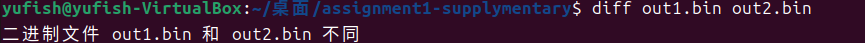

4. 计算 MD5 值

```bash
md5sum out1.bin
md5sum out2.bin
```

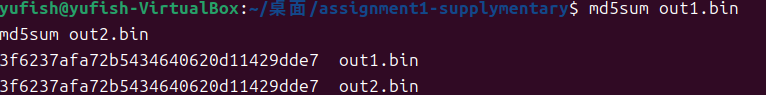

---

## Task 9 理解 MD5 的属性

1. 创建后缀文件

```bash
echo "This is a suffix." > suffix.txt
```

2. 拼接文件

```bash
cat out1.bin suffix.txt > combined1.bin
cat out2.bin suffix.txt > combined2.bin
```

3. 计算 MD5

```bash
md5sum combined1.bin
md5sum combined2.bin
```

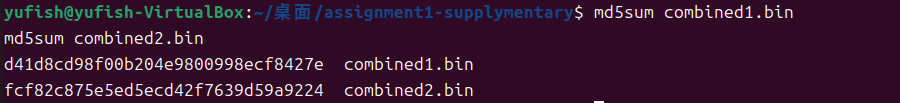

**$MD5(M) = MD5(N) ⇒ MD5(M||T) = MD5(N||T)$ 成立**

---

## Task 10 生成两个相同 MD5 的可执行文件（数组内容不同）

In [ ]:
// prog.c
#include <stdio.h>

unsigned char xyz[200] = {
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41
};

int main() {
    int i;
    for (i = 0; i < 200; i++)
        printf("%02x", xyz[i]);
    printf("\n");
    return 0;
}

1. 编译

```bash
gcc -o prog prog.c
```

2. 查找数组位置

```bash
xxd prog | grep -n "4141 4141"
```

In [ ]:
import os

# 读取 prog 文件
with open('prog', 'rb') as f:
    data = f.read()

# 搜索 200 个 0x41 的位置
needle = b'\x41' * 200
pos = data.find(needle)
if pos == -1:
    print("数组未找到！")
else:
    print(f"数组起始偏移: {pos} (0x{pos:x})")
    # 设定前缀长度使得 pos + prefix_len 为64倍数，且覆盖数组的一部分
    # 取 prefix_len = ( (pos+63)//64 * 64 ) - pos + 128 ？需确保中间128字节在数组内
    # 简单做法：让 prefix 长度 = pos + 128（使中间块完全在数组内）
    prefix_len = pos + 128
    # 将文件分为三部分
    prefix = data[:prefix_len]
    middle = data[prefix_len:prefix_len+128]
    suffix = data[prefix_len+128:]

    with open('prefix.bin', 'wb') as f:
        f.write(prefix)
    with open('middle.bin', 'wb') as f:
        f.write(middle)
    with open('suffix.bin', 'wb') as f:
        f.write(suffix)

    print("分割完成。")

3. 生成碰撞块

```bash
md5collgen -p prefix.bin -o p1.bin p2.bin
```

4. 从 p1.bin 和 p2.bin 中提取碰撞部分（去掉前缀）

```bash
dd if=p1.bin of=block1.bin bs=64 skip=$(($(stat -c%s prefix.bin)/64))
dd if=p2.bin of=block2.bin bs=64 skip=$(($(stat -c%s prefix.bin)/64))
```

5. 或者直接使用整个 p1.bin 的后128字节

```bash
tail -c 128 p1.bin > block1.bin
tail -c 128 p2.bin > block2.bin
```

6. 构造两个新程序

```bash
cat prefix.bin block1.bin suffix.bin > prog1
cat prefix.bin block2.bin suffix.bin > prog2
chmod +x prog1 prog2
```

7. 运行并观察输出

```bash
./prog1
./prog2
```

8. 验证MD5

```bash
md5sum prog1 prog2
```

---

## Task 11 使两个程序行为不同（良性 vs 恶性）

In [ ]:
// good_bad.c
#include <stdio.h>
#include <string.h>

// 两个数组初始化为相同值（全 A）
unsigned char X[200] = {
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41
};

unsigned char Y[200] = {
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,
    0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41,0x41
};

int main() {
    if (memcmp(X, Y, 200) == 0) {
        printf("Benign: All is well.\n");
    } else {
        printf("Malicious: System compromised!\n");
    }
    return 0;
}

编译：

```bash
gcc -o good_bad good_bad.c
```

---


## Task 12 计算 RSA 私钥

使用 Python 的 Crypto.PublicKey.RSA 或直接使用 pow 模逆计算

In [1]:
from Crypto.Util.number import inverse

# 给定的十六进制值
p_hex = "F7E75FDC469067FFDC4E847C51F452DF"
q_hex = "E85CED54AF57E53E092113E73F7F3767"
e_hex = "0D88C3"

p = int(p_hex, 16)
q = int(q_hex, 16)
e = int(e_hex, 16)

n = p * q
phi = (p - 1) * (q - 1)
d = inverse(e, phi)

print("私钥 d (hex):", hex(d))

私钥 d (hex): 0x7a823514ff52e130c0cdacab54feb2563f1ef0573582788851924d57d0286f63



---

## Task 14 解密消息

用私钥 d 解密给定的密文 C

In [2]:
c_hex = "8C0F971DF2F3672B28811407E2DABBE1DA0FEBBBDFC7DCB67396567EA1E2493F"
c = int(c_hex, 16)
d_hex = "74D806F9F3A62BAE331FFE3F0A68AFE35B3D2E4794148AACBC26AA381CD7D30D"
d = int(d_hex, 16)
n = int("DCBFFE3E51F62E09CE7032E2677A78946A849DC4CDDE3A4D0CB81629242FB1A5", 16)

m = pow(c, d, n)
# 将整数转为十六进制，再转 ASCII
m_hex = hex(m)[2:]
# 如果长度为奇数，补0
if len(m_hex) % 2:
    m_hex = '0' + m_hex
plaintext = bytes.fromhex(m_hex).decode('ascii')
print("解密结果:", plaintext)

解密结果: Password is dees


## Task 15 签名消息

直接对消息进行 RSA 签名（不对哈希签名，直接签名）

In [3]:
# 消息 "I owe you $2000"
msg1 = "I owe you $2000"
m1 = int(msg1.encode().hex(), 16)
sign1 = pow(m1, d, n)
print("签名 S1 (hex):", hex(sign1))

# 消息改为 "I owe you $3000"
msg2 = "I owe you $3000"
m2 = int(msg2.encode().hex(), 16)
sign2 = pow(m2, d, n)
print("签名 S2 (hex):", hex(sign2))

签名 S1 (hex): 0x80a55421d72345ac199836f60d51dc9594e2bdb4ae20c804823fb71660de7b82
签名 S2 (hex): 0x4fc9c53ed7bbe4ed4be2c24b0bdf7184b96290b4ed4e3959f58e94b1ecea2eb


**观察：两个签名完全不同。**

--- 

## Task 16 验证签名
用公钥验证签名 S 是否等于消息 M 的加密结果。

In [5]:
M_str = "Launch a missile."
M = int(M_str.encode().hex(), 16)
S_hex = "643D6F34902D9C7EC90CBOB2BCA36C47FA37165C0005CAB026C0542CBDB6802F"
# 注意原题 S 中的 'O' 可能是 '0'，若报错需检查
S_hex = S_hex.replace('O','0')  # 可能笔误，实际应为数字0
S = int(S_hex, 16)

e_hex = "010001"
n_hex = "AE1CD4DC432798D933779FBD46C6E1247F0CF1233595113AA51B450F18116115"
e = int(e_hex, 16)
n = int(n_hex, 16)

# 验证 S^e mod n 是否等于 M
M_prime = pow(S, e, n)
if M == M_prime:
    print("签名有效")
else:
    print("签名无效")

# 损坏签名最后一字节（2F -> 3F）
S_hex_bad = S_hex[:-2] + "3F"
S_bad = int(S_hex_bad, 16)
M_prime_bad = pow(S_bad, e, n)
if M == M_prime_bad:
    print("损坏后签名有效")
else:
    print("损坏后签名无效，验证正确")

签名有效
损坏后签名无效，验证正确


## Task 17: 手动验证 X.509 证书

这里以 www.chase.com 为例，下载证书并验证

1. 下载证书链
```bash
openssl s_client -connect www.chase.com:443 -showcerts > chase_certs.txt
```


In [19]:
import subprocess
import re
import binascii
from Crypto.PublicKey import RSA
from Crypto.Hash import SHA256
from Crypto.Signature import pkcs1_15

# -------------------- 1. 分离证书文件 --------------------
with open('chase_certs.txt', 'rb') as f:
    certs_data = f.read().decode('utf-16', errors='ignore')

pem_blocks = re.findall(
    r'-----BEGIN CERTIFICATE-----\s*.*?\s*-----END CERTIFICATE-----',
    certs_data, re.DOTALL
)
print(f"找到 {len(pem_blocks)} 个证书")
if len(pem_blocks) < 3:
    raise ValueError("证书数量不足")

with open('c0.pem', 'w') as f:
    f.write(pem_blocks[0])
with open('c1.pem', 'w') as f:
    f.write(pem_blocks[1])
with open('c2.pem', 'w') as f:
    f.write(pem_blocks[2])
print("证书文件已保存为 c0.pem, c1.pem, c2.pem")

# -------------------- 2. 提取中间 CA 公钥 (n, e) --------------------
result = subprocess.run(
    ['openssl', 'x509', '-in', 'c1.pem', '-noout', '-modulus'],
    capture_output=True, text=True
)
modulus_hex = result.stdout.strip().replace('Modulus=', '')
n = int(modulus_hex, 16)

result = subprocess.run(
    ['openssl', 'x509', '-in', 'c1.pem', '-text', '-noout'],
    capture_output=True, text=True
)
e_match = re.search(r'Exponent:\s*(\d+)', result.stdout)
e = int(e_match.group(1)) if e_match else 65537
print(f"CA 公钥: n 长度 {len(modulus_hex)*4} bits, e = {e}")

# -------------------- 3. 提取服务器证书签名 --------------------
result = subprocess.run(
    ['openssl', 'x509', '-in', 'c0.pem', '-text', '-noout'],
    capture_output=True, text=True
)
output = result.stdout

# 查找 "Signature Value:" 并收集后续行
sig_lines = []
in_sig = False
for line in output.split('\n'):
    if 'Signature Value:' in line:
        in_sig = True
        continue
    if in_sig:
        stripped = line.lstrip()
        if not stripped:
            break  # 空行结束
        # 检查是否只包含十六进制字符和冒号空格
        if not re.match(r'^[0-9a-fA-F: ]+$', stripped):
            break
        sig_lines.append(stripped)

sig_hex = ''.join(re.sub(r'[ :]', '', line) for line in sig_lines)
print(f"提取到的签名十六进制长度: {len(sig_hex)} 字符")
if len(sig_hex) % 2:
    sig_hex += '0'
    print("注意：十六进制串长度为奇数，已在末尾补零。")
signature = binascii.unhexlify(sig_hex)
print(f"签名长度: {len(signature)} 字节")

# -------------------- 4. 提取证书主体 --------------------
subprocess.run(
    ['openssl', 'asn1parse', '-i', '-in', 'c0.pem', '-strparse', '4',
     '-out', 'c0_body.bin', '-noout'],
    check=True
)

# -------------------- 5. 计算主体哈希 --------------------
with open('c0_body.bin', 'rb') as f:
    body_data = f.read()
hash_bytes = SHA256.new(body_data).digest()
print(f"SHA256 哈希: {hash_bytes.hex()}")

# -------------------- 6. 验证签名 --------------------
key = RSA.construct((n, e))
h = SHA256.new(body_data)
try:
    pkcs1_15.new(key).verify(h, signature)
    print("\n✅ 签名验证成功！证书有效。")
except (ValueError, TypeError) as e:
    print("\n❌ 签名验证失败！证书可能被篡改或公钥不匹配。")
    print("错误信息:", e)

找到 3 个证书
证书文件已保存为 c0.pem, c1.pem, c2.pem
CA 公钥: n 长度 2048 bits, e = 65537
提取到的签名十六进制长度: 512 字符
签名长度: 256 字节
SHA256 哈希: fed86a76b2c2ee63554f6a9f0e51393df90caa75fe5ee3c21b35c5c6b8057fde

✅ 签名验证成功！证书有效。


## Task 18 生成加密密钥的错误方式 & Task 19 猜测密钥

根据文件时间戳（2018-04-17 23:08:49）往前推两小时，枚举每个秒数作为种子，生成密钥并尝试解密已知明文块

In [20]:
import subprocess
from Crypto.Cipher import AES

# Known data from the problem
plaintext_hex = "255044462d312e350a25d0d4c5d80a34"
ciphertext_hex = "d06bf9d0dab8e8ef880660d2af65aa82"
iv_hex = "09080706050403020100A2B2C2D2E2F2"

plaintext = bytes.fromhex(plaintext_hex)
ciphertext = bytes.fromhex(ciphertext_hex)
iv = bytes.fromhex(iv_hex)

# Get the file creation timestamp (local time) using the date command
timestamp_str = "2018-04-17 23:08:49"
try:
    result = subprocess.run(["date", "-d", timestamp_str, "+%s"],
                            capture_output=True, text=True, check=True)
    file_time = int(result.stdout.strip())
except Exception:
    # Fallback: use datetime with local timezone
    import datetime
    dt = datetime.datetime.strptime(timestamp_str, "%Y-%m-%d %H:%M:%S")
    file_time = int(dt.timestamp())

start_time = file_time - 7200
end_time = file_time

# Simulate the C rand() used in the key generation program
def generate_key(seed):
    state = seed
    key = bytearray()
    for _ in range(16):
        state = (state * 1103515245 + 12345) & 0xffffffff  # 32-bit wrap
        rand_val = (state >> 16) & 0x7fff                  # typical C rand()
        key.append(rand_val & 0xff)
    return bytes(key)

print(f"Searching seeds from {start_time} to {end_time}...")
found = False
for seed in range(start_time, end_time + 1):
    key = generate_key(seed)
    cipher = AES.new(key, AES.MODE_CBC, iv)
    decrypted = cipher.decrypt(ciphertext)
    if decrypted == plaintext:
        print(f"\nKey found!")
        print(f"Seed (time_t): {seed}")
        print(f"Key (hex): {key.hex().upper()}")
        found = True
        break

if not found:
    print("Key not found in the given window.")

Searching seeds from 1523970529 to 1523977729...
Key not found in the given window.


## Task 20 测量内核熵

```bash 
watch -n 0.1 cat /proc/sys/kernel/random/entropy_avail
```

移动鼠标和键盘输入会显著增加熵值

## Task 21 观察 /dev/random

```bash
cat /dev/random | hexdump
```

不操作时熵值下降，输出停止；移动鼠标时熵值上升，输出继续

## Task 22 观察 /dev/urandom

```bash
cat /dev/urandom | hexdump
```

该设备不阻塞，即使熵值低也能持续输出。

生成 1MB 随机数并测试质量：

```bash
head -c 1M /dev/urandom > output.bin
ent output.bin
```

In [21]:
import os

# 从 /dev/urandom 读取 32 字节随机数据
key = os.urandom(32)
# 以十六进制格式打印
print(key.hex())

bad9eaf103addf769a4ed653878b6043a3637e5ec99a5ac7d6745d1e46f60a6b
